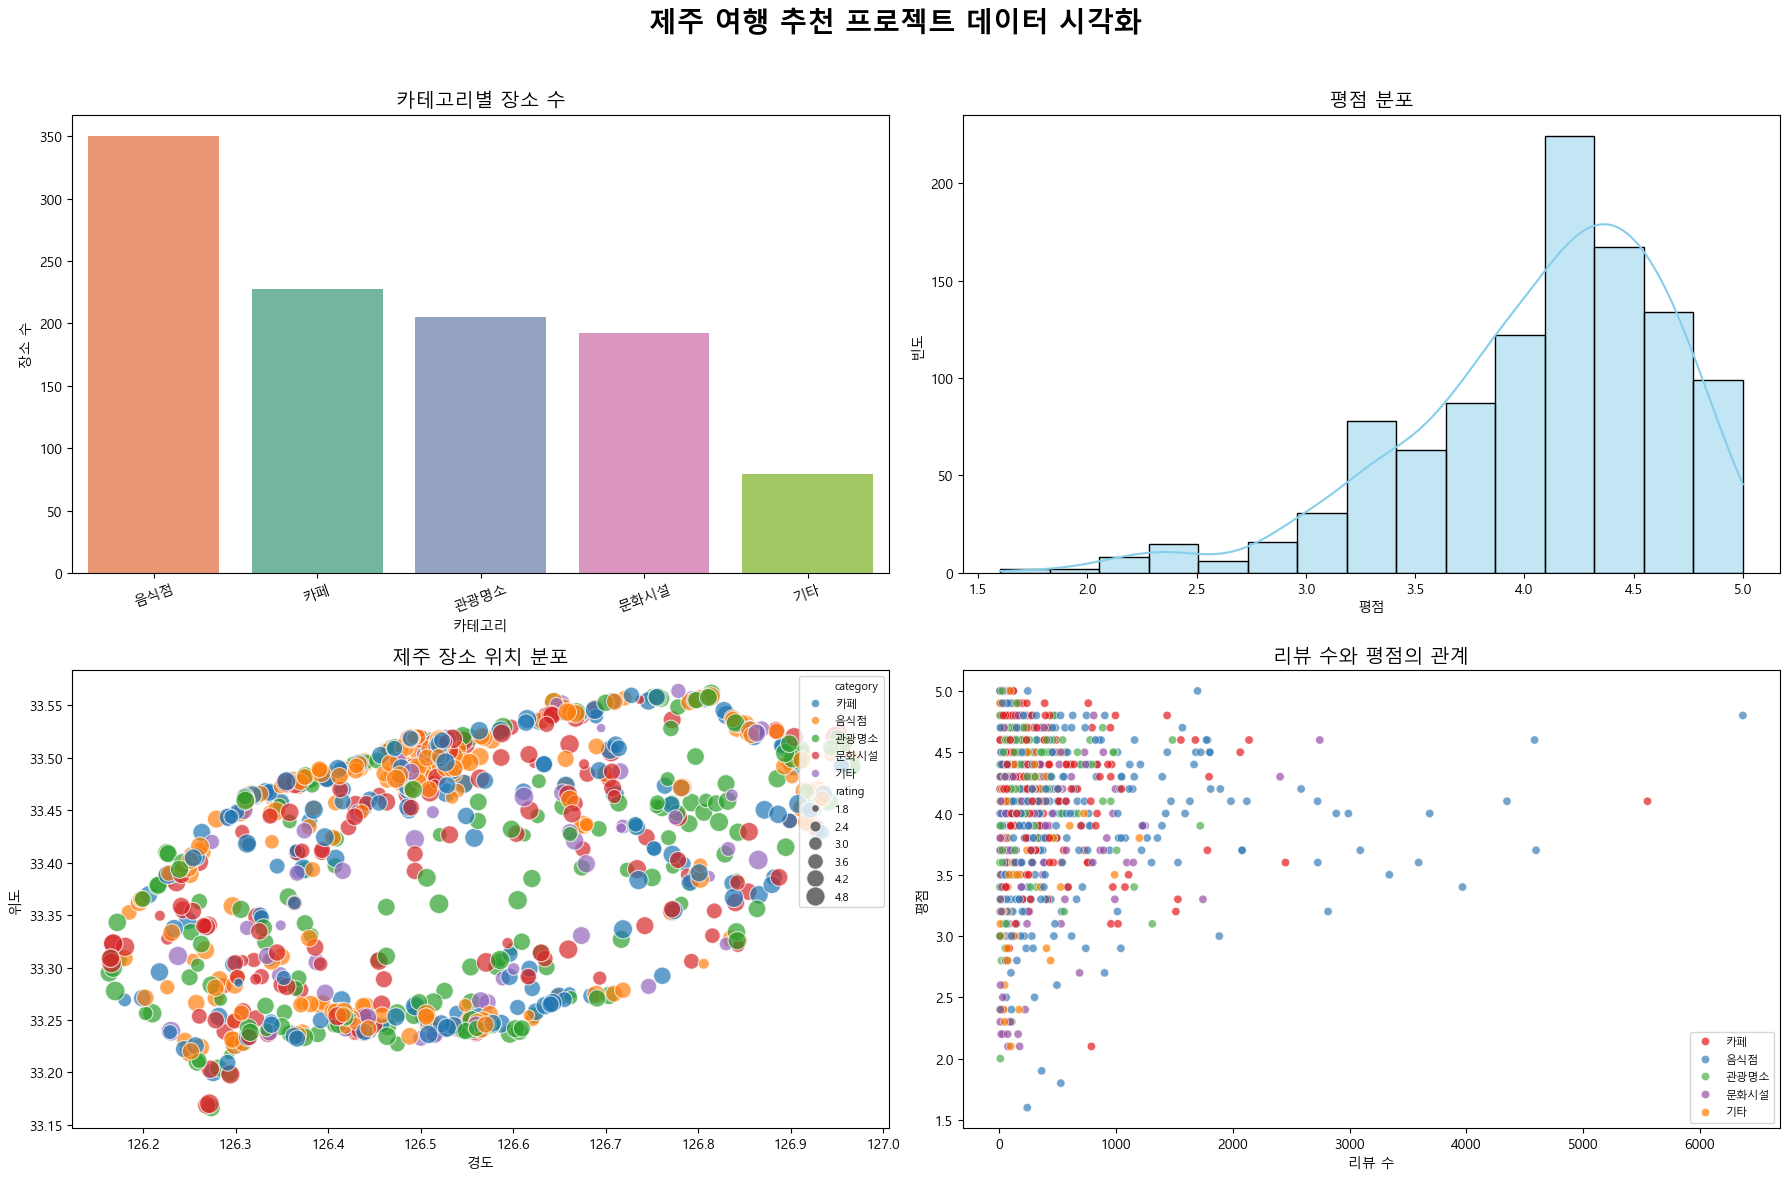

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings

# 경고 메시지 숨기기
warnings.filterwarnings("ignore")

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호가 깨지지 않도록 설정
plt.rc("axes", unicode_minus=False)


# 1. CSV 불러오기
df = pd.read_csv("jeju_crawling_100.csv", encoding="cp949")

# 2. 컬럼 이름 정리
df = df.rename(
    columns={
        "place_name": "name",
        "x": "lng",
        "y": "lat",
        "address_name": "address",
        "category_group_name": "category",
    }
)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lng"] = pd.to_numeric(df["lng"], errors="coerce")
df["total_cnt"] = pd.to_numeric(df["total_cnt"], errors="coerce").fillna(0)

df = df.dropna(subset=["lat", "lng"])

# 3. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("제주 여행 추천 프로젝트 데이터 시각화", fontsize=20, fontweight="bold")

# (1) 카테고리별 장소 수
order = df["category"].value_counts().index
sns.countplot(
    data=df,
    x="category",
    order=order,
    hue="category",
    palette="Set2",
    ax=axes[0, 0],
    legend=False,
)
axes[0, 0].set_title("카테고리별 장소 수", fontsize=14)
axes[0, 0].set_xlabel("카테고리")
axes[0, 0].set_ylabel("장소 수")
axes[0, 0].tick_params(axis="x", rotation=20)

# (2) 평점 분포
sns.histplot(df["rating"].dropna(), bins=15, kde=True, color="skyblue", ax=axes[0, 1])
axes[0, 1].set_title("평점 분포", fontsize=14)
axes[0, 1].set_xlabel("평점")
axes[0, 1].set_ylabel("빈도")

# (3) 제주 장소 위치 분포
sns.scatterplot(
    data=df,
    x="lng",
    y="lat",
    hue="category",
    size="rating",
    sizes=(20, 200),
    alpha=0.7,
    palette="tab10",
    ax=axes[1, 0],
)
axes[1, 0].set_title("제주 장소 위치 분포", fontsize=14)
axes[1, 0].set_xlabel("경도")
axes[1, 0].set_ylabel("위도")
axes[1, 0].legend(loc="upper right", fontsize=8)

# (4) 리뷰 수와 평점의 관계
sns.scatterplot(
    data=df,
    x="total_cnt",
    y="rating",
    hue="category",
    alpha=0.7,
    palette="Set1",
    ax=axes[1, 1],
)
axes[1, 1].set_title("리뷰 수와 평점의 관계", fontsize=14)
axes[1, 1].set_xlabel("리뷰 수")
axes[1, 1].set_ylabel("평점")
axes[1, 1].legend(loc='lower right', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()